# **INFORMASI DATASET**

Dataset ini menyajikan gambaran mendalam mengenai kinerja siswa dan karakteristik mata pelajaran, sehingga sangat ideal untuk eksplorasi **analisis pendidikan, evaluasi capaian belajar, dan identifikasi faktor-faktor yang mempengaruhi prestasi akademik**. Dataset ini mencakup **1.000 sampel data kinerja siswa**, yang terdiri atas berbagai atribut seperti nilai ujian, latar belakang siswa, variabel lingkungan belajar, serta informasi terkait mata pelajaran.

Setiap informasi memberikan wawasan komprehensif terhadap performa akademik siswa, memungkinkan analisis untuk **peningkatan strategi pembelajaran, pengembangan model prediktif pendidikan, dan pengambilan keputusan berbasis bukti (evidence-based)**.

# **1. Import Library**
Pada tahap ini, perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning. Semua library yang dibutuhkan harus **import** di **cell** ini

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report,accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import joblib

# **2. Memuat Dataset**
Pada tahap ini, perlu memuat dataset ke dalam notebook lalu mengecek informasi dataset sebelum nantinya dilakukan pembersihan. Hal-hal yang perlu dilakukan pada tahapan ini yaitu:
1. **Memahami Struktur Data**
   - Dataset harus mengambil referensi wajib digunakan (bisa dilihat [Disini](https://drive.google.com/drive/folders/1IlQ2E_ZgP1UC4CgxyKBSRIphZYPnC7C5?usp=drive_link))
   - Melakukan loading dataset ke dalam notebook dan menampilkan 5 baris pertama dengan function `head`.
   - Tinjau jumlah baris kolom dan jenis data dalam dataset dengan function `info`.  
   - Menampilkan statistik deskriptif dataset dengan menjalankan `describe`.
   - Pastikan **setiap function tersebut** memiliki **output pada setiap cell** code.
   

Gunakan code ini untuk melakukan load data secara otomatis tanpa harus download data tersebut secara manual:
```python
url='https://docs.google.com/spreadsheets/d/e/2PACX-1vSD3RV_L4ZwPCsCnT8Ba8OorOVSl6IzuLFA85oqEfbRORoN7AJQaGyJqVneapmGiwdkLJ6IByqrei-Z/pub?output=csv'
df = pd.read_csv(url)
```

In [ ]:
# Load data

### MULAI CODE ###

url='https://docs.google.com/spreadsheets/d/e/2PACX-1vSD3RV_L4ZwPCsCnT8Ba8OorOVSl6IzuLFA85oqEfbRORoN7AJQaGyJqVneapmGiwdkLJ6IByqrei-Z/pub?output=csv'
df = pd.read_csv(url)

### SELESAI CODE ###

In [ ]:
# Tampilkan 5 baris pertama dengan function head.

### MULAI CODE ###

df.head()

### SELESAI CODE ###

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.

### MULAI CODE ###

df.info()

### SELESAI CODE ###

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe

### MULAI CODE ###

df.describe(include="all")

### SELESAI CODE ###

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
count,1000,1000,1000,1000,1000,1000.00000,1000.000000,1000.000000
unique,2,5,6,2,2,NaN,NaN,NaN
top,female,group C,some college,standard,none,NaN,NaN,NaN
freq,518,319,226,645,642,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,66.08900,69.169000,68.054000
std,NaN,NaN,NaN,NaN,NaN,15.16308,14.600192,15.195657
min,NaN,NaN,NaN,NaN,NaN,0.00000,17.000000,10.000000
25%,NaN,NaN,NaN,NaN,NaN,57.00000,59.000000,57.750000
50%,NaN,NaN,NaN,NaN,NaN,66.00000,70.000000,69.000000
75%,NaN,NaN,NaN,NaN,NaN,77.00000,79.000000,79.000000


Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA)

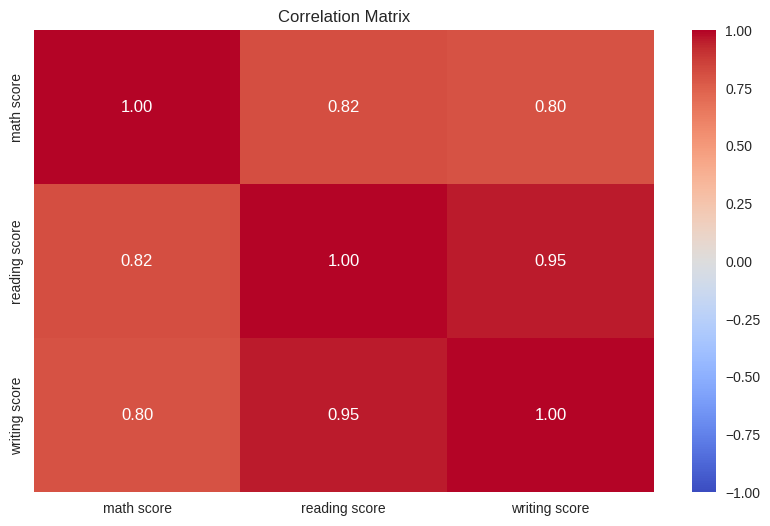

In [ ]:
# Menampilkan korelasi antar fitur

# Memilih kolom numerik
numerical_cols = df.select_dtypes(include=['number']).columns

### MULAI CODE ###

# Hitung matriks korelasi
correlation = df[numerical_cols].corr()

# Buat visualisasi heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation,
               annot=True,
               cmap='coolwarm',
               fmt=".2f",
               vmin=-1,
               vmax=1)
plt.title('Correlation Matrix')
plt.show()

### SELESAI CODE ###

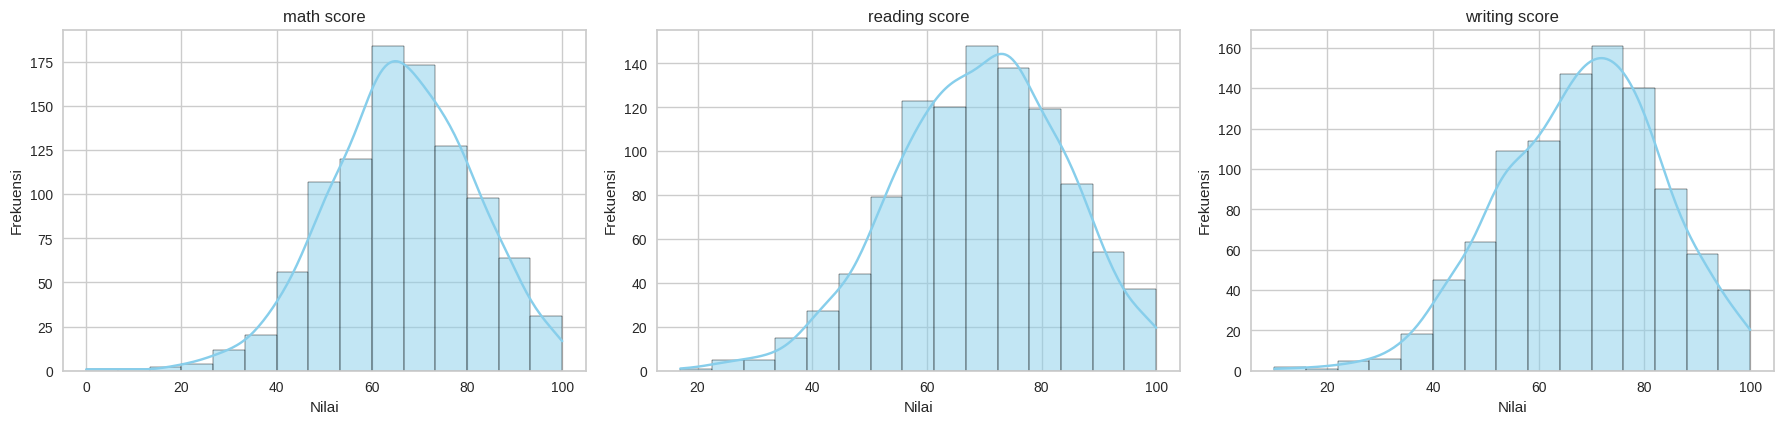

In [ ]:
# Menampilkan histogram untuk semua kolom numerik

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, column in enumerate(numerical_cols):
    if i < len(axes): # Add a check to ensure index is within bounds
    ### MULAI CODE ###

    # Tampilkan histogram dan pastikan plot ditempatkan di subplot (axes) yang benar
        sns.histplot(df[column], bins=15, kde=True, color='skyblue', ax=axes[i])

    # Atur judul dan label
        axes[i].set_title(column)
        axes[i].set_xlabel("Nilai")
        axes[i].set_ylabel("Frekuensi")

    ### SELESAI CODE ###

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# **3. Pembersihan dan Pra Pemrosesan Data**

Pada tahap ini, akan melakukan **Pembersihan Dataset** untuk menjadikan dataset mudah diintepretasi dan bisa dilatih. Hal-hal yang wajib dilakukan yaitu:

1. **Mengecek dataset** menggunakan isnull().sum() dan duplicated().sum().
2. Melakukan drop pada data null/nan dan data yang duplicate.
4. Melakukan feature encoding menggunakan `LabelEncoder()` untuk fitur kategorikal.
5. **Ketentuan Cell Code**
   - Pastikan **setiap pemeriksaan tersebut** memiliki **output pada cell-nya**.

In [ ]:
# Mengecek dataset menggunakan isnull().sum()

### MULAI CODE ###

df.isnull().sum()

### SELESAI CODE ###

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0
math score group,0


In [ ]:
# Mengecek dataset menggunakan duplicated().sum()

### MULAI CODE ###

df.duplicated().sum()

### SELESAI CODE ###

np.int64(0)

In [ ]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.
# Pastikan menggunakan function head setelah melalukan encoding.

### MULAI CODE ###

# Pilih semua kolom yang bertipe 'object' (kategorikal)
categorical_cols = list(df.select_dtypes(include=['object']).columns)

encoders = {}

# Loop melalui setiap kolom kategorikal
for column in categorical_cols:
    # Buat (instantiate) objek LabelEncoder
    label_encoder = LabelEncoder()

    # Terapkan (fit) encoder ke data dan sekaligus ubah (transform) data tersebut
    df[column] = label_encoder.fit_transform(df[column])

    # Simpan encoder
    encoders[column] = label_encoder

# Tampilkan 5 baris pertama untuk memverifikasi hasil encoding
df.head()

### SELESAI CODE ###

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,math score group
0,0,1,1,1,1,72,72,74,1
1,0,2,4,1,0,69,90,88,1
2,0,1,3,1,1,90,95,93,0
3,1,0,0,0,1,47,57,44,2
4,1,2,4,1,1,76,78,75,0


In [ ]:
from sklearn.base import check_array

# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada.

# Perbaiki kode di bawah ini tanpa menambahkan atau mengurangi cell code ini.

### MULAI CODE ###

df.columns.tolist()

### SELESAI CODE ###

['gender',
 'race/ethnicity',
 'parental level of education',
 'lunch',
 'test preparation course',
 'math score',
 'reading score',
 'writing score']

In [ ]:
# Mengecek duplikat pada kolom "race/ethnicity"
duplicate_rows = df[df['race/ethnicity'].duplicated()]

duplicate_count = len(duplicate_rows)
duplicate_count

995

In [ ]:
# Ambil dua kolom utama: race/ethnicity dan parental level of education
# df = df[["race/ethnicity", "parental level of education"]]  # Kolom race/ethnicity: 'race/ethnicity', label: 'circular'
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,1,1,1,1,72,72,74
1,0,2,4,1,0,69,90,88
2,0,1,3,1,1,90,95,93
3,1,0,0,0,1,47,57,44
4,1,2,4,1,1,76,78,75


# Menghapus duplikat berdasarkan kolom 'race/ethnicity' dan mempertahankan baris pertama yang ditemukan
df_no_duplicates = df.drop_duplicates(subset='race/ethnicity', keep='first')

# Menampilkan hasil setelah duplikat
duplicate_count = len(df_no_duplicates)
print("Jumlah data setelah dihapus duplikat:", duplicate_count)


In [ ]:
df['race/ethnicity'].value_counts()

,count
race/ethnicity,
2,315
3,261
1,183
4,139
0,88


In [ ]:
from numpy._core.defchararray import upper
# Melakukan Handling Outlier Data menggunakan metode drop.

# Definisikan numerical_cols
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in numerical_cols:

    ### MULAI CODE ###

    # Hitung Kuartil 1 (Q1) dan Kuartil 3 (Q3)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Hitung Interquartile Range (IQR)
    IQR = Q3 - Q1

    # Tentukan batas bawah (lower bound) dan batas atas (upper bound)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter DataFrame: Simpan hanya baris di mana nilai 'df[col]' berada DI ANTARA (inklusif) batas bawah dan batas atas.
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

    ### SELESAI CODE ###

# Tampilkan statistik deskriptif setelah outlier dihapus
df.describe()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
count,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000
mean,0.483773,2.182556,2.474645,0.651116,0.637931,66.694726,69.723124,68.648073
std,0.499990,1.157250,1.830887,0.476859,0.480843,14.340780,13.910716,14.427092
min,0.000000,0.000000,0.000000,0.000000,0.000000,27.000000,31.000000,32.000000
25%,0.000000,1.000000,1.000000,0.000000,0.000000,57.000000,60.000000,58.000000
50%,0.000000,2.000000,2.000000,1.000000,1.000000,66.500000,70.000000,69.000000
75%,1.000000,3.000000,4.000000,1.000000,1.000000,77.000000,80.000000,79.000000
max,1.000000,4.000000,5.000000,1.000000,1.000000,100.000000,100.000000,100.000000


In [ ]:
# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik,
# lakukan pada satu sampai dua fitur numerik.
# Silahkan lakukan encode hasil binning tersebut menggunakan LabelEncoder.
# Pastikan kamu mengerjakan tahapan ini pada satu cell.

### MULAI CODE ###

# Tentukan kolom numerik yang ingin Anda kelompokkan
col_to_bin = 'math score'  # (Isi dengan 'math score' atau kolom numerik lain)

# Tentukan nama untuk kolom kategori baru
new_col_name = 'math score group'

# Tentukan label untuk 3 grup (Anda dapat menentukan nama label-nya sendiri)
# Mulai dari sangat rendah --> rendah --> cukup
bin_labels = ['very low', 'low', 'fair']

# Gunakan 'pd.qcut' untuk membagi data menjadi 3 kelompok
df[new_col_name] = pd.qcut(df[col_to_bin], q=3, labels=bin_labels, duplicates='drop')

# Lakukan Label Encoding pada kolom baru ini agar menjadi numerik
label_encoder = LabelEncoder()
df[new_col_name] = label_encoder.fit_transform(df[new_col_name])

# Simpan encoder dan tambahkan nama kolom baru ke 'categorical_cols'
encoders[new_col_name] = label_encoder
categorical_cols.extend([new_col_name])

# Tampilkan 5 baris pertama untuk memverifikasi
df.head()

### SELESAI CODE ###

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,math score group
0,0,1,1,1,1,72,72,74,1
1,0,2,4,1,0,69,90,88,1
2,0,1,3,1,1,90,95,93,0
3,1,0,0,0,1,47,57,44,2
4,1,2,4,1,1,76,78,75,0


# **4. Membangun Model Clustering**
Pada tahap ini, membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan.
1. Pastikan Anda menggunakan dataframe yang sudah melalui processing sesuai dengan kebutuhannya.
2. Melakukan visualisasi Elbow Method untuk menentukan jumlah cluster terbaik menggunakan `KElbowVisualizer()`.
3. Menggunakan algoritma K-Means Clustering dengan `sklearn.cluster.KMeans()`.
4. Jalankan cell code `joblib.dump(model_kmeans, "model_clustering.h5")` untuk menyimpan model yang sudah dibuat.

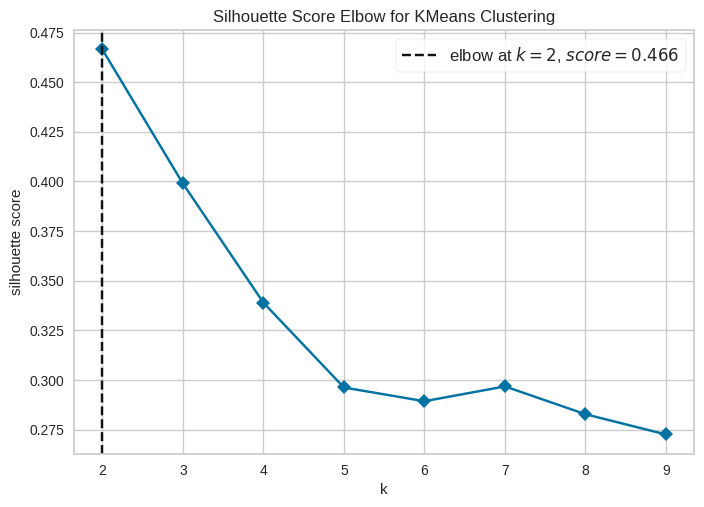

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [ ]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()

# Buat (instantiate) model clustering
model = KMeans()

### MULAI CODE ###

# Buat (instantiate) KElbowVisualizer
#  - Masukkan 'model' yang akan digunakan
#  - Tentukan jumlah cluster yang akan diuji (range 2 sampai 10)
#  - Tentukan 'metric' evaluasi
visualizer = KElbowVisualizer(model,
                       k=(2,10),
                       metric='silhouette',
                       timings=False)

# Jalankan (fit) visualizer pada data
visualizer.fit(df)

# Tampilkan plot
visualizer.show()

### SELESAI CODE ###

In [ ]:
# Menggunakan algoritma K-Means Clustering

### MULAI CODE ###

# Buat (instantiate) objek model KMeans
#  - Tentukan jumlah cluster (n_clusters)
kmeans = KMeans(n_clusters=2, random_state=42)

# Latih (fit) model dengan data Anda (df)
kmeans.fit(df)

### SELESAI CODE ###

KMeans(n_clusters=2, random_state=42)

Jalankan cell code ini untuk menyimpan model clustering.

In [ ]:
# Menyimpan model menggunakan joblib

### MULAI CODE ###

# Simpan model clustering yang sudah dilatih
joblib.dump(kmeans, "model_clustering.h5")

### SELESAI CODE ###

['model_clustering.h5']